In [1]:
import os
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../data/dataset_selection_sans_leger.csv"
df = pd.read_csv(csv_path)

# Vérifications rapides
assert "path" in df.columns and "label" in df.columns, "Le CSV doit contenir 'path' et 'label'"
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

# Optionnel: filtrer les fichiers manquants
df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants dans le CSV. Je les enlève.")
    df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)
else:
    df = df.drop(columns=["exists"])




In [2]:
# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val/test (80/10/10)
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Dataset + Transforms
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        y = int(self.df.loc[idx, "y"])

        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, y

train_ds  = FundusDataset(train_df, transform=train_tfms)
val_ds    = FundusDataset(val_df,   transform=val_tfms)
test_ds   = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle (Transfer Learning)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/mathis/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s] 


In [3]:


best_val_acc = 0.0
epochs = 10

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")


Epoch 01 | train loss 0.5347 acc 0.7847 | val loss 0.3849 acc 0.8406
Epoch 02 | train loss 0.3334 acc 0.8681 | val loss 0.3341 acc 0.8567
Epoch 03 | train loss 0.2764 acc 0.8903 | val loss 0.3505 acc 0.8663
Epoch 04 | train loss 0.2167 acc 0.9190 | val loss 0.3842 acc 0.8502
Epoch 05 | train loss 0.1775 acc 0.9333 | val loss 0.3052 acc 0.8921
Epoch 06 | train loss 0.1494 acc 0.9410 | val loss 0.2995 acc 0.8841
Epoch 07 | train loss 0.1357 acc 0.9474 | val loss 0.3081 acc 0.8841
Epoch 08 | train loss 0.1102 acc 0.9607 | val loss 0.3655 acc 0.8663
Epoch 09 | train loss 0.0646 acc 0.9776 | val loss 0.2725 acc 0.9002
Epoch 10 | train loss 0.0479 acc 0.9837 | val loss 0.2887 acc 0.9098


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import torch

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    y_proba = []  # softmax probabilities

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            preds = probs.argmax(dim=1).cpu().numpy()
            y_pred.append(preds)

            y_true.append(y.cpu().numpy())
            y_proba.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_proba = np.concatenate(y_proba)  # (N, C)
    return y_true, y_pred, y_proba

def binary_metrics_from_cm(cm):
    # cm = [[TN, FP],
    #       [FN, TP]]
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn + 1e-12)   # TPR / Recall
    spec = tn / (tn + fp + 1e-12)   # TNR
    ppv  = tp / (tp + fp + 1e-12)   # Precision
    npv  = tn / (tn + fn + 1e-12)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    return {"acc": acc, "sens": sens, "spec": spec, "ppv": ppv, "npv": npv}

def multiclass_sens_spec(cm):
    # One-vs-rest sensitivity & specificity per class
    C = cm.shape[0]
    total = cm.sum()
    out = []
    for k in range(C):
        tp = cm[k, k]
        fn = cm[k, :].sum() - tp
        fp = cm[:, k].sum() - tp
        tn = total - tp - fn - fp
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        out.append((sens, spec))
    return out

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix (val)", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    # values in cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i, j]:.2f}" if normalize else str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            141              0         2            12
True_glaucome             0            148         0             7
True_mda                  2              0       146             8
True_normaux              8              8        16           123


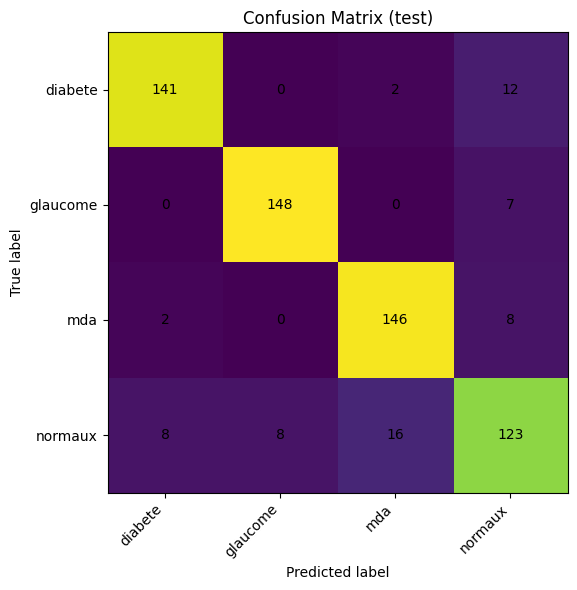


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.9338    0.9097    0.9216       155
    glaucome     0.9487    0.9548    0.9518       155
         mda     0.8902    0.9359    0.9125       156
     normaux     0.8200    0.7935    0.8066       155

    accuracy                         0.8986       621
   macro avg     0.8982    0.8985    0.8981       621
weighted avg     0.8982    0.8986    0.8981       621



In [5]:

# =========================
# UTILISATION (après entraînement)
# =========================

# device, model, test_loader, le, num_classes doivent déjà exister dans ton script

y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


In [6]:
import numpy as np
from PIL import Image
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    """
    img: PIL RGB
    thr: seuil (0-255). Plus haut => enlève plus (attention à ne pas rogner l'image utile)
    pad: marge ajoutée autour du crop
    """
    arr = np.array(img)  # H,W,3 uint8
    gray = arr.mean(axis=2)  # H,W

    mask = gray > thr  # True = zone utile
    if not mask.any():
        return img  # image totalement sombre -> on ne touche pas

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # padding + clamp aux bords
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)

    return img.crop((x0, y0, x1 + 1, y1 + 1))

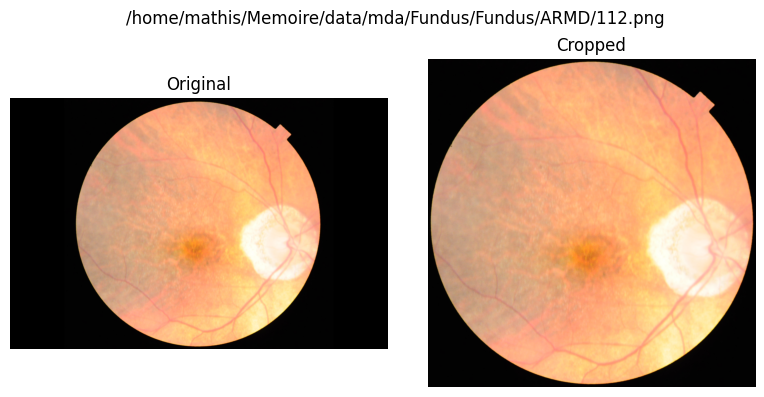

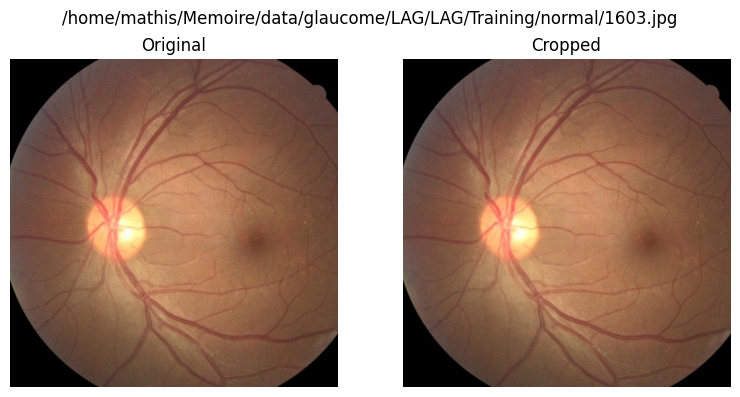

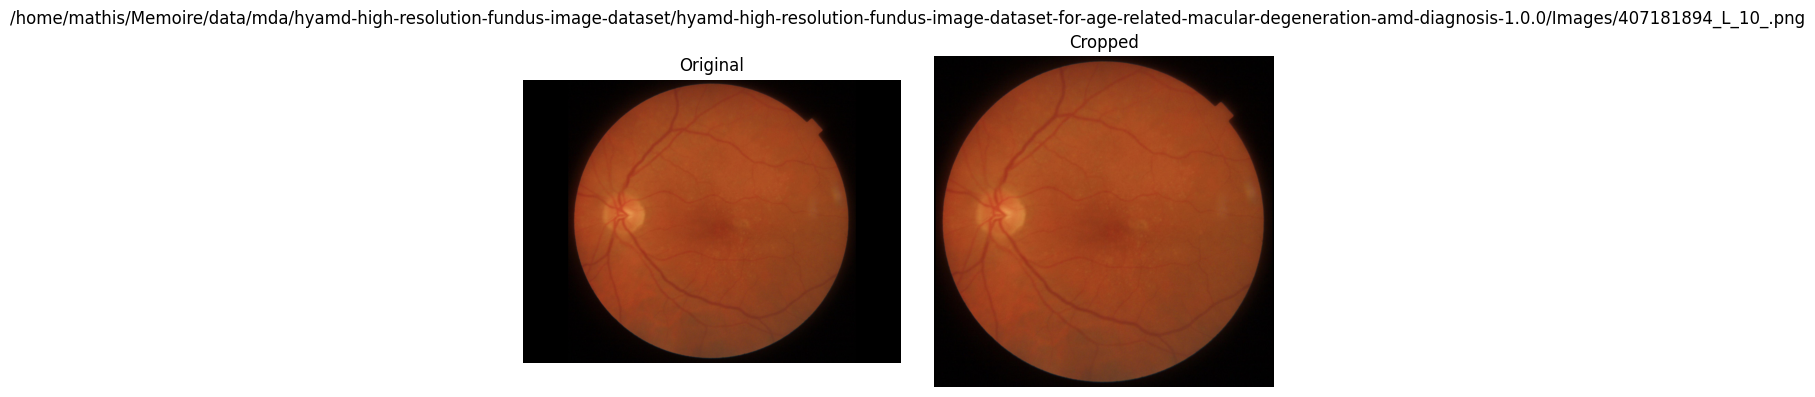

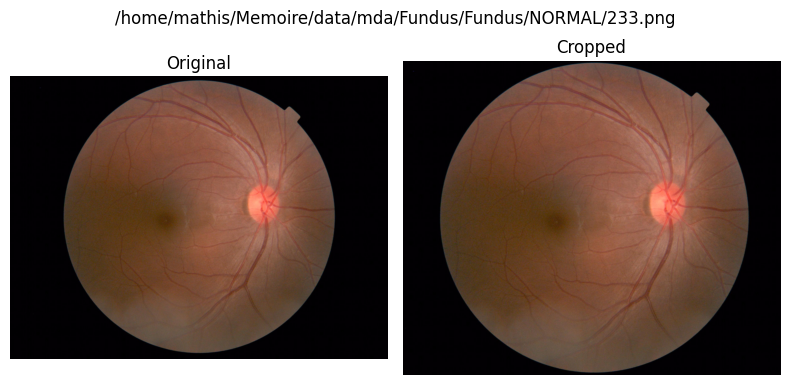

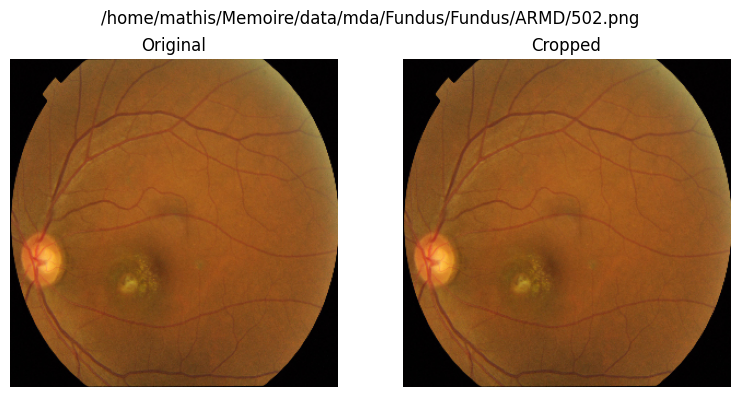

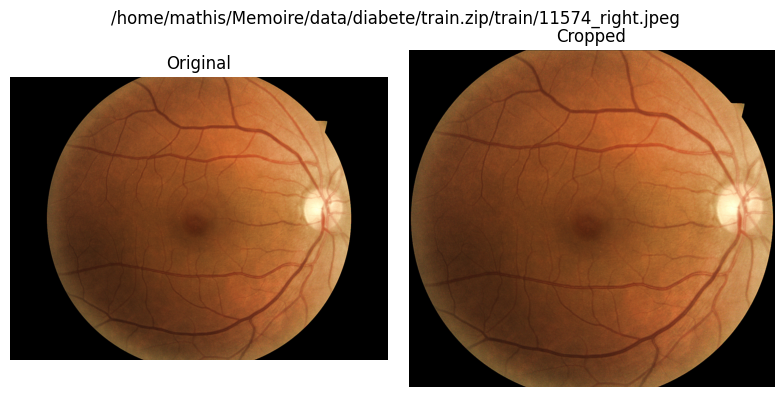

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

sample_paths = df["path"].sample(6, random_state=0).tolist()

for p in sample_paths:
    img = Image.open(p).convert("RGB")
    cropped = crop_black_border_pil(img, thr=10, pad=10)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cropped)
    axes[1].set_title("Cropped")
    axes[1].axis("off")

    fig.suptitle(p)
    plt.tight_layout()
    plt.show()


In [ ]:
# -------------------------
# 2) Encoder les labels
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

# -------------------------
# 3) Split train/val/test (80/10/10)
# -------------------------
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)

test_df, val_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 4) Dataset + Transforms
# -------------------------
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["path"]
        y = int(row["y"])

        img = Image.open(path).convert("RGB")

        if self.do_crop:
            img = crop_black_border_pil(img, thr=10, pad=10)

        if self.transform:
            img = self.transform(img)

        return img, y


train_ds  = FundusDataset(train_df, transform=train_tfms)
val_ds    = FundusDataset(val_df,   transform=val_tfms)
test_ds   = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# -------------------------
# 5) Modèle (Transfer Learning)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

# -------------------------
# 6) Entraînement + Évaluation
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total

best_val_acc = 0.0
epochs = 10

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621
Epoch 01 | train loss 0.5371 acc 0.7940 | val loss 0.4590 acc 0.8132
Epoch 02 | train loss 0.3240 acc 0.8762 | val loss 0.3893 acc 0.8519
Epoch 03 | train loss 0.2591 acc 0.9025 | val loss 0.3405 acc 0.8680
Epoch 04 | train loss 0.2114 acc 0.9188 | val loss 0.4108 acc 0.8647
Epoch 05 | train loss 0.1634 acc 0.9376 | val loss 0.3615 acc 0.8680
Epoch 06 | train loss 0.1573 acc 0.9428 | val loss 0.3250 acc 0.8873
Epoch 07 | train loss 0.1155 acc 0.9561 | val loss 0.3583 acc 0.8889
Epoch 08 | train loss 0.1061 acc 0.9599 | val loss 0.4549 acc 0.8583
Epoch 09 | train loss 0.1016 acc 0.9652 | val loss 0.4062 acc 0.8615
Epoch 10 | train loss 0.0788 acc 0.9716 | val loss 0.3485 acc 0.8776



=== Confusion Matrix (test) avec labels ===
               Pred_diabete  Pred_glaucome  Pred_mda  Pred_normaux
True_diabete            133              1         2            19
True_glaucome             0            151         0             4
True_mda                  0              0       145            11
True_normaux              5             11        12           127


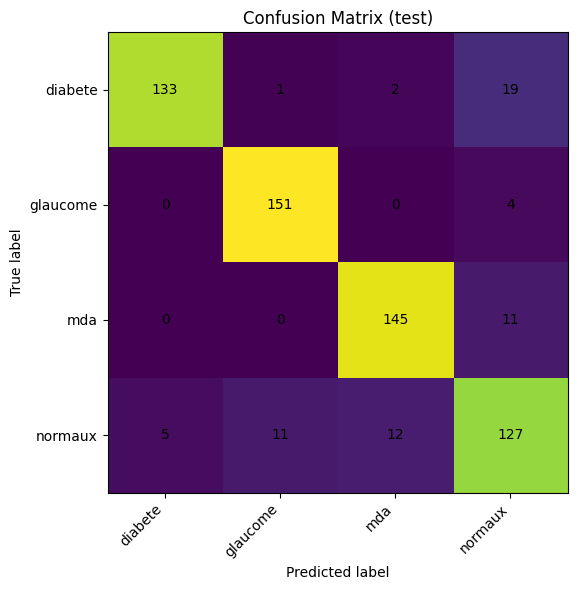


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.9638    0.8581    0.9078       155
    glaucome     0.9264    0.9742    0.9497       155
         mda     0.9119    0.9295    0.9206       156
     normaux     0.7888    0.8194    0.8038       155

    accuracy                         0.8953       621
   macro avg     0.8977    0.8953    0.8955       621
weighted avg     0.8978    0.8953    0.8955       621



In [9]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion + noms (texte)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in le.classes_],
    columns=[f"Pred_{c}" for c in le.classes_]
)
print("\n=== Confusion Matrix (test) avec labels ===")
print(cm_df)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


2026-03-02 18:36:39.981305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 18:36:40.791185: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 18:36:44.643586: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Nombre d'images mal classées : 65


I0000 00:00:1772473005.846378  223267 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4211 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


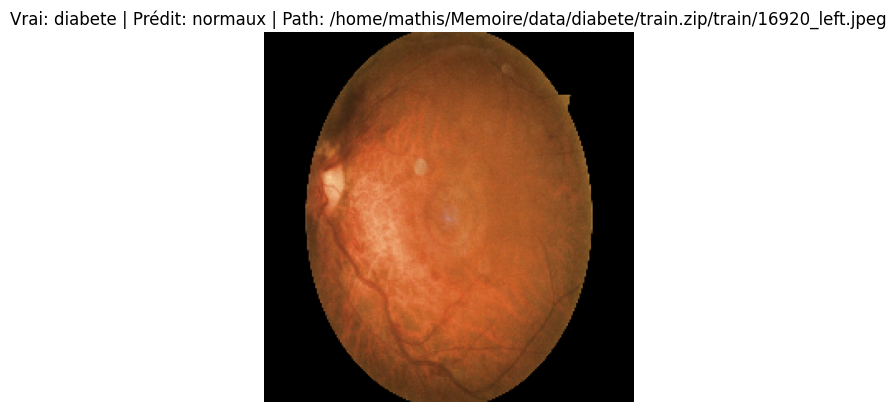

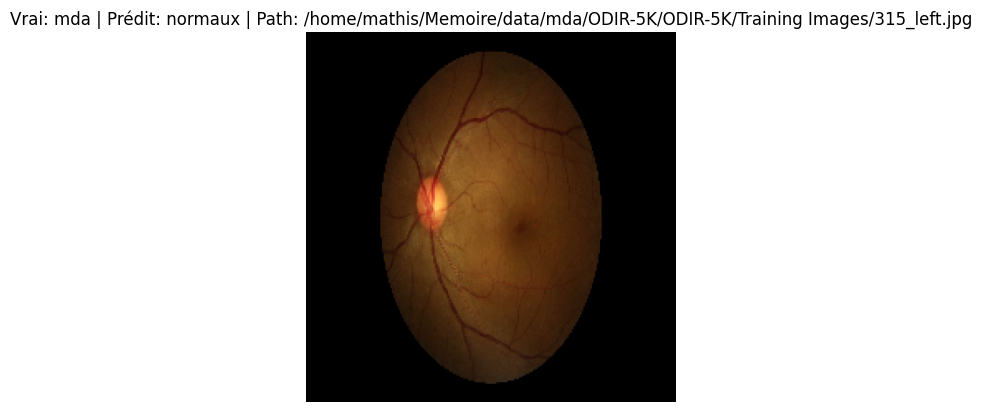

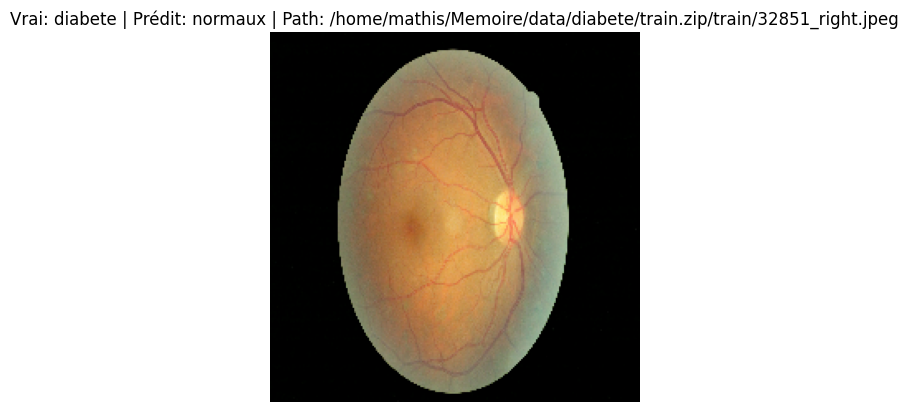

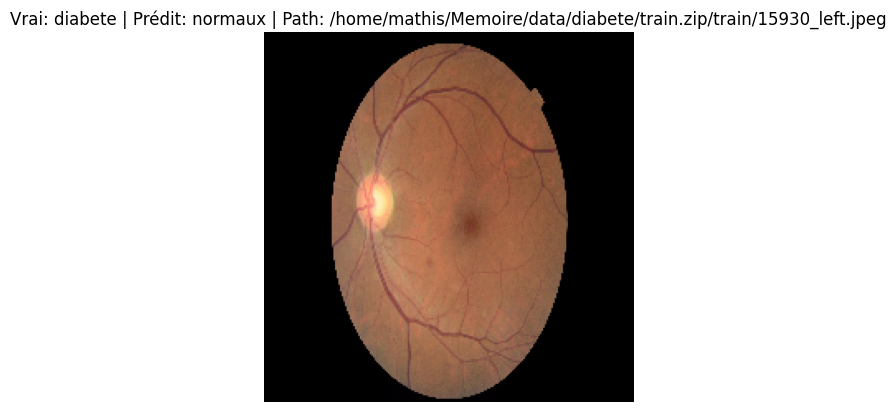

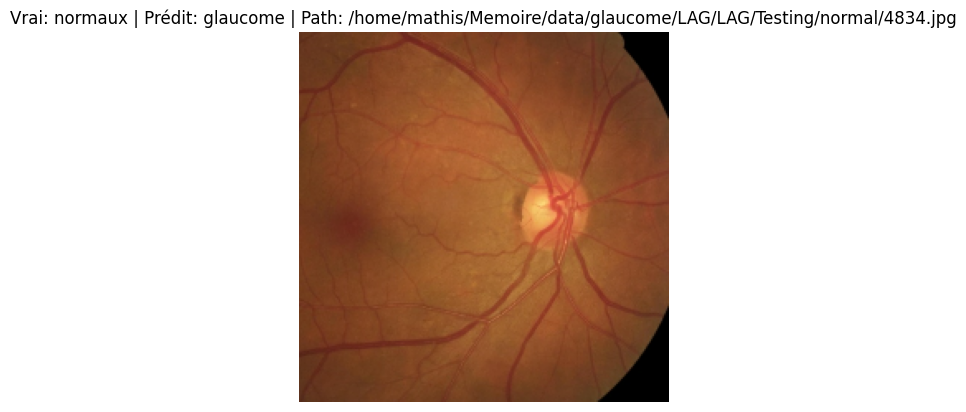

In [10]:
#montre des exemples d'images mal classées
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
df_test = test_df.reset_index(drop=True)
classes = le.classes_
IMG = 224
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")   
for idx in misclassified_indices[:5]:  # Affiche les 5 premières erreurs
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [IMG, IMG])

    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label} | Path: {img_path}")
    plt.axis("off")
    plt.show()

In [11]:

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=5, factor=0.5)

best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0

    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} train acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} val acc {va_acc:.4f} | "
          f"lr {current_lr:.2e} "
          )

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping déclenché à l'epoch {epoch}")
        break



Epoch 01 | train loss 0.0791 train acc 0.9708 | val loss 0.4405 val acc 0.8744 | lr 1.00e-04 
Epoch 02 | train loss 0.0698 train acc 0.9742 | val loss 0.4338 val acc 0.8857 | lr 1.00e-04 
Epoch 03 | train loss 0.0803 train acc 0.9720 | val loss 0.4419 val acc 0.8857 | lr 1.00e-04 
Epoch 04 | train loss 0.0627 train acc 0.9797 | val loss 0.3628 val acc 0.8857 | lr 1.00e-04 
Epoch 05 | train loss 0.0522 train acc 0.9837 | val loss 0.4243 val acc 0.8857 | lr 1.00e-04 
Epoch 06 | train loss 0.0451 train acc 0.9837 | val loss 0.4007 val acc 0.8808 | lr 1.00e-04 
Epoch 07 | train loss 0.0893 train acc 0.9652 | val loss 0.4212 val acc 0.8937 | lr 1.00e-04 
Epoch 08 | train loss 0.0593 train acc 0.9807 | val loss 0.4270 val acc 0.8889 | lr 1.00e-04 
Epoch 09 | train loss 0.0350 train acc 0.9879 | val loss 0.3905 val acc 0.8969 | lr 1.00e-04 
Epoch 10 | train loss 0.0582 train acc 0.9768 | val loss 0.3997 val acc 0.8712 | lr 1.00e-04 
Epoch 11 | train loss 0.0491 train acc 0.9837 | val loss 0.4

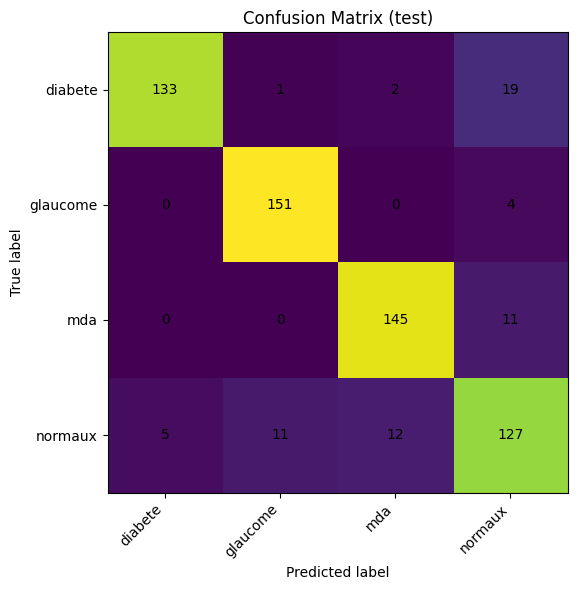

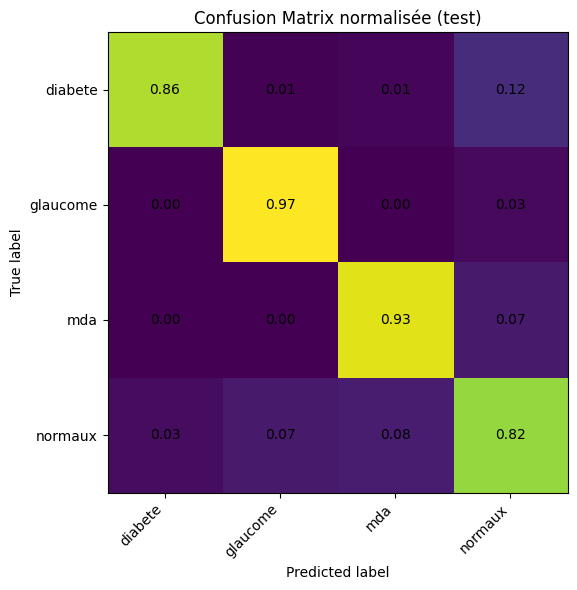


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.9231    0.9290    0.9260       155
    glaucome     0.9375    0.9677    0.9524       155
         mda     0.9255    0.9551    0.9401       156
     normaux     0.8472    0.7871    0.8161       155

    accuracy                         0.9098       621
   macro avg     0.9083    0.9097    0.9086       621
weighted avg     0.9083    0.9098    0.9087       621



In [12]:
y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)

# ---- Matrice de confusion (figure)
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix (test)")
plot_confusion_matrix(cm, class_names=list(le.classes_), title="Confusion Matrix normalisée (test)", normalize=True)

# ---- Rapport complet
print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))

Nombre d'images mal classées : 56


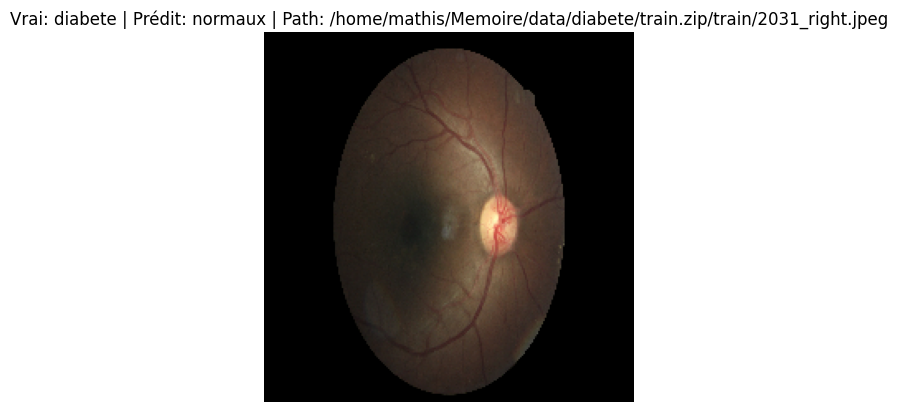

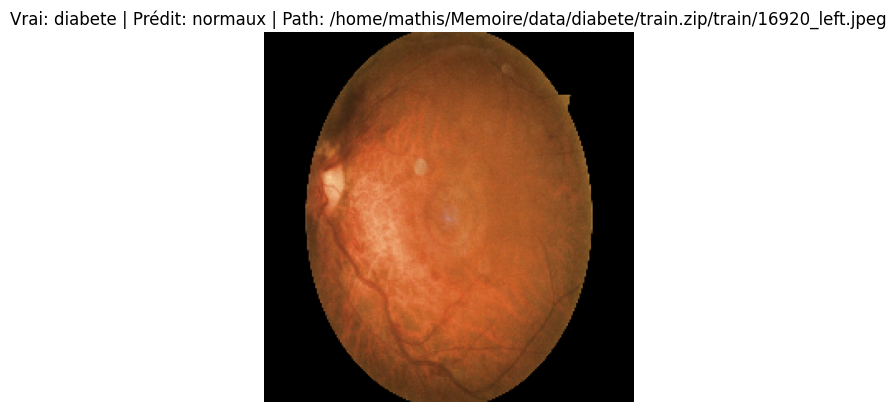

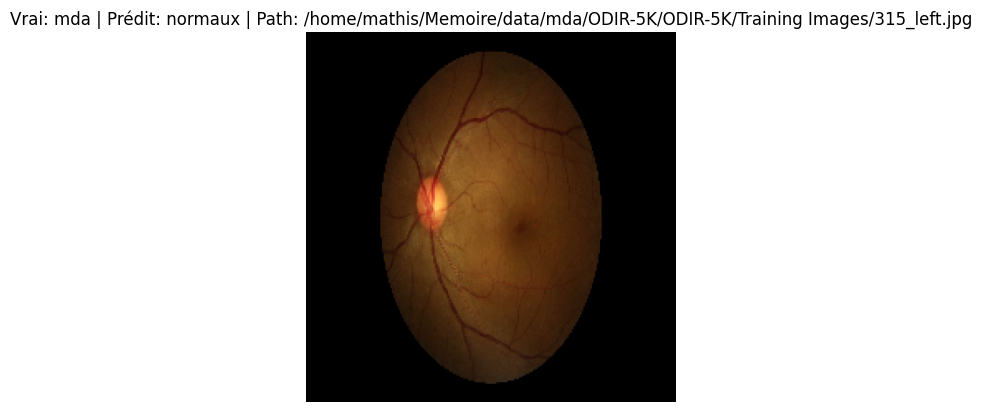

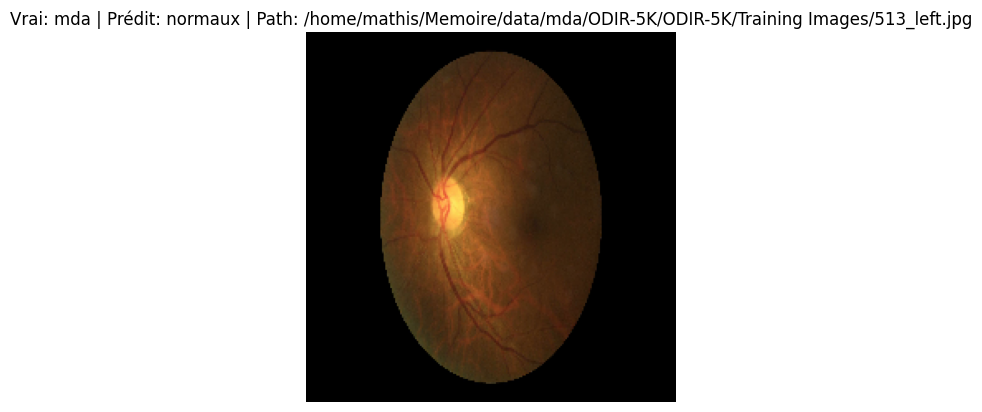

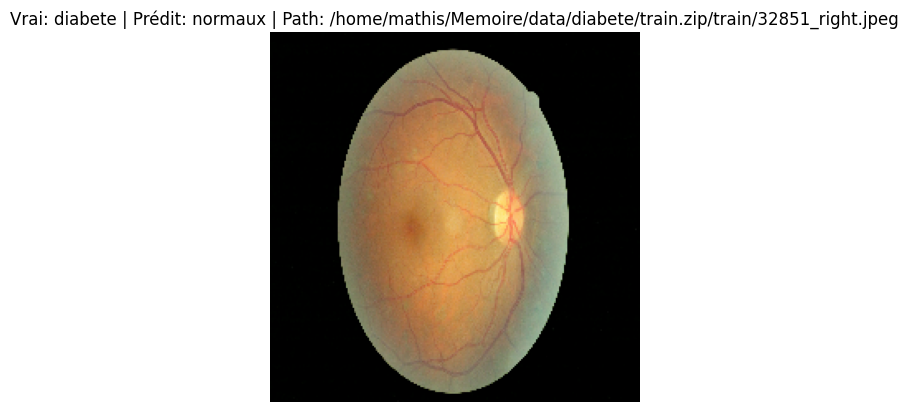

In [13]:
#montre des exemples d'images mal classées
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
df_test = test_df.reset_index(drop=True)
classes = le.classes_
IMG = 224
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")   
for idx in misclassified_indices[:5]:  # Affiche les 5 premières erreurs
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]

    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [IMG, IMG])

    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label} | Path: {img_path}")
    plt.axis("off")
    plt.show()